In [10]:
import os, sys
ROOT    = "/teamspace/studios/this_studio/misinformation-detection"
DATA    = f"{ROOT}/data/pheme"
OUTPUTS = f"{ROOT}/outputs"
SRC     = f"{ROOT}/src"

sys.path.append(SRC)  # so you can import from src/

print("DATA exists   :", os.path.exists(DATA))
print("Events found  :", os.listdir(DATA))

DATA exists   : True
Events found  : ['README', 'charliehebdo', 'ferguson', 'germanwings-crash', 'ottawashooting', 'sydneysiege']


In [11]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime

print("All imports OK")

All imports OK


In [13]:
from load_cascade import load_cascade   # imported from src/
# step 1 — update load_cascade.py in src/ with the fixed version above
# then reload it

import importlib
import sys

# remove cached version
if 'load_cascade' in sys.modules:
    del sys.modules['load_cascade']

from load_cascade import load_cascade

# step 2 — reload all cascades
all_cascades = []

for event in os.listdir(DATA):
    event_path = os.path.join(DATA, event)
    if not os.path.isdir(event_path): continue
    for label_name in ['rumours', 'non-rumours']:
        label_path = os.path.join(event_path, label_name)
        if not os.path.exists(label_path): continue
        label = 1 if label_name == 'rumours' else 0
        threads = [t for t in os.listdir(label_path)
                   if os.path.isdir(os.path.join(label_path, t))]
        for thread in tqdm(threads, desc=f"{event}/{label_name}"):
            t_dir = os.path.join(label_path, thread)
            try:
                G, _, root_id = load_cascade(t_dir)
                all_cascades.append((G, label, root_id, event))
            except Exception as e:
                print(f"skipped {thread}: {e}")

print(f"Reloaded: {len(all_cascades)} cascades")

print(f"\nLoaded  : {len(all_cascades)} cascades")
print(f"Rumours : {sum(1 for _,l,_,_ in all_cascades if l==1)}")
print(f"Non-rum : {sum(1 for _,l,_,_ in all_cascades if l==0)}")

sydneysiege/non-rumours: 100%|██████████| 699/699 [00:03<00:00, 214.28it/s]

Reloaded: 5802 cascades

Loaded  : 5802 cascades
Rumours : 1972
Non-rum : 3830


In [31]:
import pickle

# Save all_cascades graphs so BiGCN notebook can load them directly
# Each entry: (G, label, root_id, event)
# G is a networkx DiGraph with node attrs: text, timestamp, etc.

cascade_data = []
for G, label, root_id, event in all_cascades:
    cascade_data.append({
        'root_id'  : root_id,
        'label'    : label,
        'event'    : event,
        'nodes'    : list(G.nodes(data=True)),
        'edges'    : list(G.edges(data=True)),
    })

with open(f'{OUTPUTS}/all_cascades.pkl', 'wb') as f:
    pickle.dump(cascade_data, f)

print(f"Saved {len(cascade_data)} cascades to all_cascades.pkl")

Saved 5802 cascades to all_cascades.pkl


In [14]:

# remove cached version
if 'features' in sys.modules:
    del sys.modules['features']
    
from features import compute_features
rows = []
for G, label, root_id, event in tqdm(all_cascades, desc="extracting features"):
    feats = compute_features(G, root_id)
    feats['label'] = label
    feats['event'] = event
    feats['root_id'] = root_id
    rows.append(feats)

df = pd.DataFrame(rows)

print(df.shape)
print(df.head())
print("\nClass balance:")
print(df['label'].value_counts())
print("\nFeature stats:")
print(df[['depth','branching','size','growth_30m','burstiness']].describe())

extracting features: 100%|██████████| 5802/5802 [00:00<00:00, 10875.76it/s]

(5802, 8)
   depth  branching  size  growth_30m  burstiness  label         event  \
0      5          5    10           3      0.0258      1  charliehebdo   
1      3          5     8           6      0.3913      1  charliehebdo   
2      1          5     6           4      0.0579      1  charliehebdo   
3     10          3    14           9      0.2704      1  charliehebdo   
4      5         10    17          15      0.3533      1  charliehebdo   

              root_id  
0  552783238415265792  
1  552783667052167168  
2  552783745565347840  
3  552784168849907712  
4  552784526955806720  

Class balance:
label
0    3830
1    1972
Name: count, dtype: int64

Feature stats:
             depth    branching         size   growth_30m   burstiness
count  5802.000000  5802.000000  5802.000000  5802.000000  5802.000000
mean      3.477422     9.583592    17.851086     9.049810     0.226555
std       3.905926     6.699370    20.284867     8.283115     0.268864
min       0.000000     0.000000  

In [15]:
OUTPUTS = '/teamspace/studios/this_studio/misinformation-detection/outputs'

df.to_csv(f'{OUTPUTS}/cascade_features.csv', index=False)
print("Saved to cascade_features.csv")

Saved to cascade_features.csv


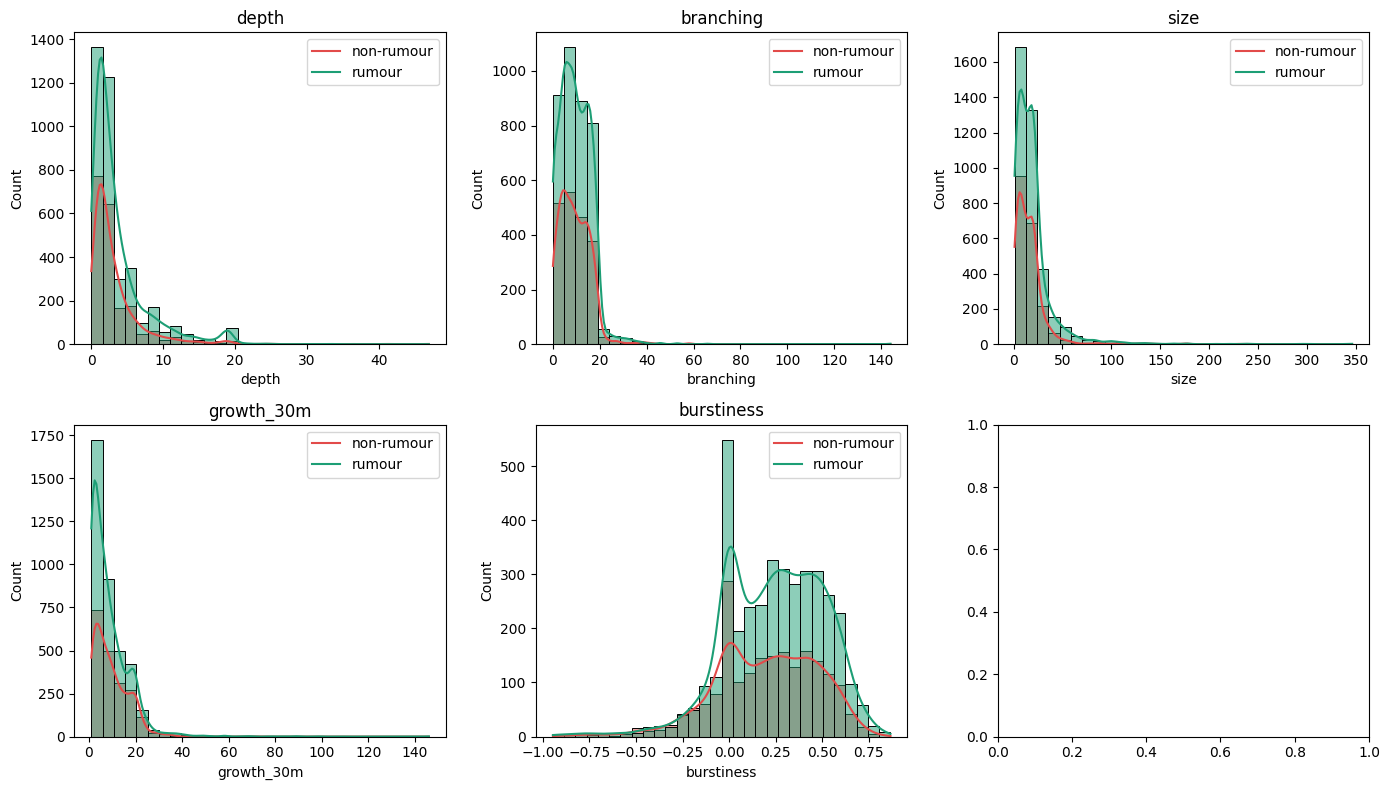

Plot saved


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features  = ['depth','branching','size','growth_30m','burstiness']

for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feat, hue='label',
                 bins=30, kde=True, ax=ax,
                 palette={0:'#1D9E75', 1:'#E24B4A'})
    ax.set_title(feat)
    ax.legend(['non-rumour','rumour'])

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/feature_distributions.png', dpi=150)
plt.show()
print("Plot saved")

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, classification_report)
import pickle

# --- load features ---
df = pd.read_csv(f'{OUTPUTS}/cascade_features.csv')

# define feature groups
STRUCTURAL = ['depth', 'branching', 'size']
TEMPORAL   = ['growth_30m', 'burstiness']
ALL_FEATS  = STRUCTURAL + TEMPORAL

X_struct   = df[STRUCTURAL].values
X_temporal = df[TEMPORAL].values
X_all      = df[ALL_FEATS].values
y          = df['label'].values

print(f"Dataset: {len(y)} cascades, {y.mean():.2%} rumour")

Dataset: 5802 cascades, 33.99% rumour


In [18]:
def evaluate_rf(X, y, name, cv_folds=5):
    """Train RF with stratified k-fold and return results."""
    
    rf = RandomForestClassifier(
        n_estimators  = 100,
        max_depth     = None,
        max_features  = 'sqrt',
        class_weight  = 'balanced',   # critical for PHEME imbalance
        random_state  = 42,
        n_jobs        = -1
    )
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # collect predictions across all folds
    y_pred  = np.zeros(len(y), dtype=int)
    y_proba = np.zeros(len(y))
    
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        rf.fit(X_train, y_train)
        y_pred[val_idx]  = rf.predict(X_val)
        y_proba[val_idx] = rf.predict_proba(X_val)[:, 1]
    
    # compute metrics
    macro_f1  = f1_score(y, y_pred, average='macro')
    precision = precision_score(y, y_pred, average='macro')
    recall    = recall_score(y, y_pred, average='macro')
    roc_auc   = roc_auc_score(y, y_proba)
    
    print(f"\n{'='*50}")
    print(f"Model: Random Forest — {name}")
    print(f"{'='*50}")
    print(f"Macro-F1  : {macro_f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(y, y_pred,
                                target_names=['non-rumour','rumour']))
    
    # fit final model on all data for feature importance
    rf.fit(X, y)
    
    return {
        'name'      : name,
        'model'     : rf,
        'macro_f1'  : macro_f1,
        'precision' : precision,
        'recall'    : recall,
        'roc_auc'   : roc_auc,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
    }

# --- train all three variants ---
results = {}
results['structural'] = evaluate_rf(X_struct,   y, 'structural only')
results['temporal']   = evaluate_rf(X_temporal, y, 'temporal only')
results['all']        = evaluate_rf(X_all,       y, 'all features')


Model: Random Forest — structural only
Macro-F1  : 0.5112
Precision : 0.5181
Recall    : 0.5200
ROC-AUC   : 0.5250

Per-class report:
              precision    recall  f1-score   support

  non-rumour       0.68      0.55      0.61      3830
      rumour       0.36      0.49      0.41      1972

    accuracy                           0.53      5802
   macro avg       0.52      0.52      0.51      5802
weighted avg       0.57      0.53      0.54      5802


Model: Random Forest — temporal only
Macro-F1  : 0.5376
Precision : 0.5383
Recall    : 0.5373
ROC-AUC   : 0.5559

Per-class report:
              precision    recall  f1-score   support

  non-rumour       0.68      0.70      0.69      3830
      rumour       0.39      0.37      0.38      1972

    accuracy                           0.59      5802
   macro avg       0.54      0.54      0.54      5802
weighted avg       0.59      0.59      0.59      5802


Model: Random Forest — all features
Macro-F1  : 0.5305
Precision : 0.5469
Rec

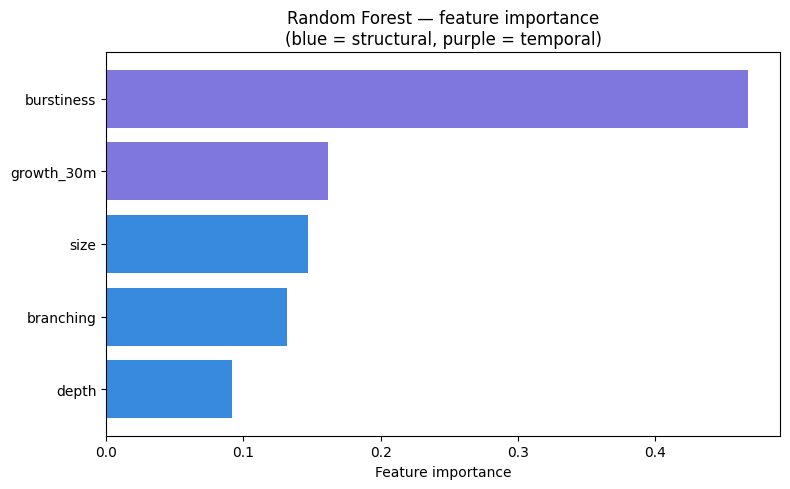

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_all = results['all']['model']

importance_df = pd.DataFrame({
    'feature'   : ALL_FEATS,
    'importance': rf_all.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#7F77DD' if f in TEMPORAL else '#378ADD'
          for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest — feature importance\n(blue = structural, purple = temporal)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/rf_feature_importance.png', dpi=150)
plt.show()

30 min   | structural   | Macro-F1: 0.5103
30 min   | temporal     | Macro-F1: 0.5375
30 min   | all          | Macro-F1: 0.5304
60 min   | structural   | Macro-F1: 0.5103
60 min   | temporal     | Macro-F1: 0.5375
60 min   | all          | Macro-F1: 0.5304
120 min  | structural   | Macro-F1: 0.5103
120 min  | temporal     | Macro-F1: 0.5375
120 min  | all          | Macro-F1: 0.5304
Full     | structural   | Macro-F1: 0.5103
Full     | temporal     | Macro-F1: 0.5375
Full     | all          | Macro-F1: 0.5304


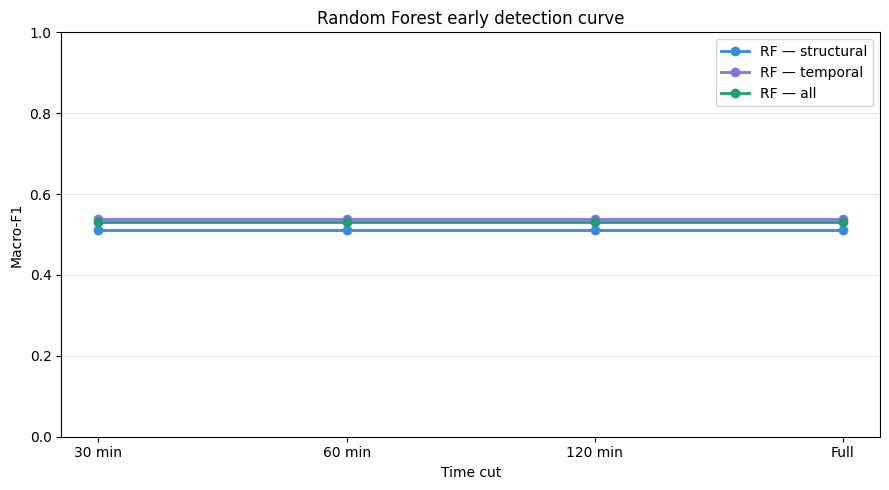

In [20]:
def apply_time_cut(df, cut_minutes):
    """
    Simulate early detection by zeroing out features
    that depend on tweets after the cut.
    growth_30m stays if cut >= 30, else scale it down.
    time_to_peak gets capped at cut.
    """
    df_cut = df.copy()
    
    if cut_minutes < 30:
        # only a fraction of 30-min growth is visible
        scale = cut_minutes / 30
        df_cut['growth_30m']   = (df_cut['growth_30m'] * scale).astype(int)
      
    return df_cut

cuts = [30, 60, 120, None]   # None = full cascade
cut_labels = ['30 min', '60 min', '120 min', 'Full']
early_results = {'structural': [], 'temporal': [], 'all': []}

for cut, cut_label in zip(cuts, cut_labels):
    df_cut = apply_time_cut(df, cut) if cut else df
    
    X_s = df_cut[STRUCTURAL].values
    X_t = df_cut[TEMPORAL].values
    X_a = df_cut[ALL_FEATS].values
    
    for variant, X in [('structural', X_s),
                       ('temporal',   X_t),
                       ('all',        X_a)]:
        rf = RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=42, n_jobs=-1
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')
        early_results[variant].append(scores.mean())
        print(f"{cut_label:8s} | {variant:12s} | Macro-F1: {scores.mean():.4f}")

# plot early detection curve
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'structural': '#378ADD', 'temporal': '#7F77DD', 'all': '#1D9E75'}

for variant, f1s in early_results.items():
    ax.plot(cut_labels, f1s, marker='o', linewidth=2,
            color=colors[variant], label=f'RF — {variant}')

ax.set_xlabel('Time cut')
ax.set_ylabel('Macro-F1')
ax.set_title('Random Forest early detection curve')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/rf_early_detection_curve.png', dpi=150)
plt.show()

In [21]:
for name, res in results.items():
    path = f'{OUTPUTS}/rf_{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(res['model'], f)
    print(f"Saved {path}")

# save early detection numbers for later comparison with BiGCN
pd.DataFrame(early_results, index=cut_labels).to_csv(
    f'{OUTPUTS}/rf_early_detection_scores.csv'
)
print("All saved.")

Saved /teamspace/studios/this_studio/misinformation-detection/outputs/rf_structural.pkl
Saved /teamspace/studios/this_studio/misinformation-detection/outputs/rf_temporal.pkl
Saved /teamspace/studios/this_studio/misinformation-detection/outputs/rf_all.pkl
All saved.


In [22]:
texts  = [G.nodes[root_id].get('text', '') for G, _, root_id, _ in all_cascades]
labels = [l for _, l, _, _ in all_cascades]

print(f"texts : {len(texts)}")
print(f"labels: {len(labels)}")

texts : 5802
labels: 5802


In [23]:
import json

with open(f'{OUTPUTS}/texts_and_labels.json', 'w') as f:
    json.dump({'texts': texts, 'labels': labels}, f)
print("Saved — won't need to reload again")

Saved — won't need to reload again


In [24]:
#bert

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [25]:
# --- dataset class ---
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [26]:
# --- training function for one fold ---
def train_bert_fold(train_texts, train_labels, val_texts, val_labels,
                    tokenizer, epochs=3, batch_size=32, lr=2e-5):

    train_dataset = TweetDataset(train_texts, train_labels, tokenizer)
    val_dataset   = TweetDataset(val_texts,   val_labels,   tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                              shuffle=False)

    # load fresh model for each fold
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels  = 2,
        hidden_dropout_prob = 0.1
    ).to(device)

    # class weights for imbalance
    n_neg = sum(1 for l in train_labels if l == 0)
    n_pos = sum(1 for l in train_labels if l == 1)
    weight = torch.tensor([1.0, n_neg/n_pos], dtype=torch.float).to(device)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = total_steps // 10,
        num_training_steps = total_steps
    )

    # --- training loop ---
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"  Epoch {epoch+1}/{epochs}",
                          leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids      = input_ids,
                            attention_mask = attention_mask,
                            labels         = labels_batch)

            # apply class weights manually
            loss_fn = torch.nn.CrossEntropyLoss(weight=weight)
            loss    = loss_fn(outputs.logits, labels_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        print(f"  Epoch {epoch+1} loss: {total_loss/len(train_loader):.4f}")

    # --- evaluation ---
    model.eval()
    all_preds  = []
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            outputs = model(input_ids      = input_ids,
                            attention_mask = attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

In [27]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

texts_arr  = np.array(texts)
labels_arr = np.array(labels)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds  = np.zeros(len(labels_arr), dtype=int)
all_probs  = np.zeros(len(labels_arr))

for fold, (train_idx, val_idx) in enumerate(cv.split(texts_arr, labels_arr)):
    print(f"\nFold {fold+1}/5")

    train_texts  = texts_arr[train_idx].tolist()
    train_labels = labels_arr[train_idx].tolist()
    val_texts    = texts_arr[val_idx].tolist()
    val_labels   = labels_arr[val_idx].tolist()

    preds, probs, _ = train_bert_fold(
        train_texts, train_labels,
        val_texts,   val_labels,
        tokenizer
    )

    all_preds[val_idx] = preds
    all_probs[val_idx] = probs

# --- final metrics ---
macro_f1  = f1_score(labels_arr, all_preds, average='macro')
roc_auc   = roc_auc_score(labels_arr, all_probs)

print(f"\n{'='*50}")
print(f"Model: BERT (text-only, source tweet)")
print(f"{'='*50}")
print(f"Macro-F1  : {macro_f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"\nPer-class report:")
print(classification_report(labels_arr, all_preds,
                             target_names=['non-rumour', 'rumour']))


Fold 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 loss: 0.5198


  Epoch 2 loss: 0.3200


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 loss: 0.4843


  Epoch 2 loss: 0.3114


  Epoch 3 loss: 0.2094

Model: BERT (text-only, source tweet)
Macro-F1  : 0.8470
ROC-AUC   : 0.9333

Per-class report:
              precision    recall  f1-score   support

  non-rumour       0.92      0.85      0.89      3830
      rumour       0.75      0.86      0.81      1972

    accuracy                           0.86      5802
   macro avg       0.84      0.86      0.85      5802
weighted avg       0.87      0.86      0.86      5802



In [28]:
# save predictions for early detection eval later
np.save(f'{OUTPUTS}/bert_preds.npy',  all_preds)
np.save(f'{OUTPUTS}/bert_probs.npy',  all_probs)
print("BERT predictions saved")

BERT predictions saved


In [29]:
import pandas as pd

bert_results = {
    'model'        : 'BERT',
    'macro_f1'     : round(macro_f1, 4),
    'roc_auc'      : round(roc_auc, 4),
}

pd.DataFrame([bert_results]).to_csv(f'{OUTPUTS}/bert_results.csv', index=False)
print("BERT results saved")
print(bert_results)

BERT results saved
{'model': 'BERT', 'macro_f1': 0.847, 'roc_auc': 0.9333}


In [30]:
from transformers import BertModel

bert_encoder = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_encoder.eval()

def get_embeddings(texts_list, tokenizer, model, batch_size=64):
    all_embeddings = []
    for i in tqdm(range(0, len(texts_list), batch_size), desc="extracting embeddings"):
        batch_texts = texts_list[i:i+batch_size]
        encoding = tokenizer(
            batch_texts,
            max_length     = 128,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs    = model(input_ids=input_ids,
                               attention_mask=attention_mask)
            embeddings = outputs.last_hidden_state[:, 0, :]
        
        all_embeddings.append(embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

source_embeddings = get_embeddings(texts, tokenizer, bert_encoder)
print(f"Embeddings shape: {source_embeddings.shape}")

np.save(f'{OUTPUTS}/source_tweet_embeddings.npy', source_embeddings)
print("Saved source_tweet_embeddings.npy")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
extracting embeddings: 100%|██████████| 91/91 [00:35<00:00,  2.59it/s]

Embeddings shape: (5802, 768)
Saved source_tweet_embeddings.npy


In [32]:
import json
import numpy as np
import torch
from tqdm import tqdm
from transformers import BertTokenizer, BertModel

# --- collect all node texts in a fixed order ---
node_ids   = []
node_texts = []

for G, label, root_id, event in all_cascades:
    for node_id in G.nodes():
        text = G.nodes[node_id].get('text', '')
        if not text or text.strip() == '':
            text = ''   # fallback — BERT handles empty string fine
        node_ids.append(node_id)
        node_texts.append(text)

print(f"Total nodes to embed : {len(node_ids)}")

# --- save the id->index mapping ---
node_id_to_idx = {str(nid): idx for idx, nid in enumerate(node_ids)}
with open(f'{OUTPUTS}/node_id_to_idx.json', 'w') as f:
    json.dump(node_id_to_idx, f)
print("Saved node_id_to_idx.json")

# --- embed all nodes ---
tokenizer    = BertTokenizer.from_pretrained('bert-base-uncased')
bert_encoder = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_encoder.eval()

def get_embeddings(texts_list, tokenizer, model, batch_size=64):
    all_embeddings = []
    for i in tqdm(range(0, len(texts_list), batch_size), desc="embedding nodes"):
        batch_texts = texts_list[i:i+batch_size]
        encoding = tokenizer(
            batch_texts,
            max_length     = 128,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        with torch.no_grad():
            outputs    = bert_encoder(input_ids=input_ids,
                                      attention_mask=attention_mask)
            embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

all_node_embeddings = get_embeddings(node_texts, tokenizer, bert_encoder)
print(f"Embeddings shape: {all_node_embeddings.shape}")  # (103572, 768)

np.save(f'{OUTPUTS}/all_node_embeddings.npy', all_node_embeddings)
print("Saved all_node_embeddings.npy")

Total nodes to embed : 103572
Saved node_id_to_idx.json


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
embedding nodes: 100%|██████████| 1619/1619 [10:35<00:00,  2.55it/s]


Embeddings shape: (103572, 768)
Saved all_node_embeddings.npy
